In [ ]:
!pip install ISLP
from ISLP import load_data
import seaborn as sns
import matplotlib.pyplot as plt
auto = load_data('Auto')

- mpg(Miles per gallon): how many miles a car can drive per gallon of fuel (fuel efficiency)
- mpg01: 1 if mpg is above the median (high fuel efficiency), 0 if below the median (low fuel efficiency)
- cylinders: Number of cylinders in the car's engine
- displacement: Engine displacement: total volume of all cylinders (usually in cubic inches or cc)
- horsepower: Engine power, measured in horsepower
- weight: Weight of the car (pounds or kilograms)
- acceleration: Time it takes to accelerate from 0 to 60 mph (seconds)
- year: Model year of the car
- origin: Origin of the car (usually coded as a number representing country/region)

####14. In this problem, you will develop a model to predict whether a given car gets high or low gas mileage based on the Auto data set.
####(a) Create a binary variable, mpg01, that contains a 1 if mpg contains a value above its median, and a 0 if mpg contains a value below its median. You can compute the median using the median() method of the data frame. Note you may find it helpful to add a column mpg01 to the data frame by assignment. Assuming you have stored the data frame as Auto, this can be done as follows: Auto['mpg01'] = mpg01

In [ ]:
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1


In [ ]:
mpg_median = auto['mpg'].median()
auto['mpg01'] = (auto['mpg'] > mpg_median).astype(int)
print("Median mpg:", mpg_median)
print(auto[['mpg', 'mpg01']].head())

Median mpg: 22.75
                            mpg  mpg01
name                                  
chevrolet chevelle malibu  18.0      0
buick skylark 320          15.0      0
plymouth satellite         18.0      0
amc rebel sst              16.0      0
ford torino                17.0      0


####(b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.

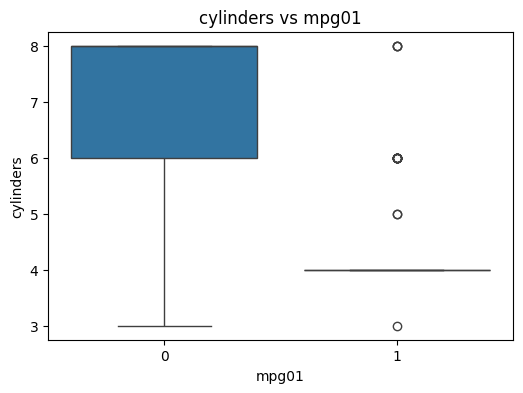

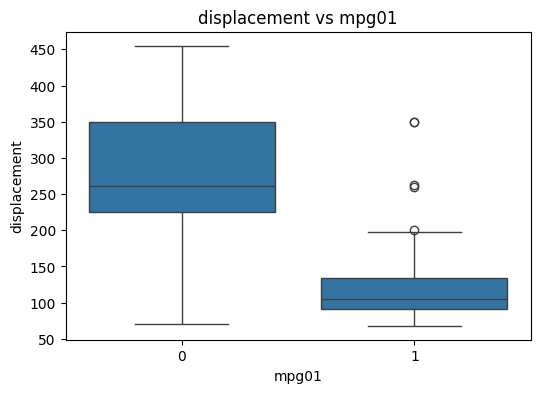

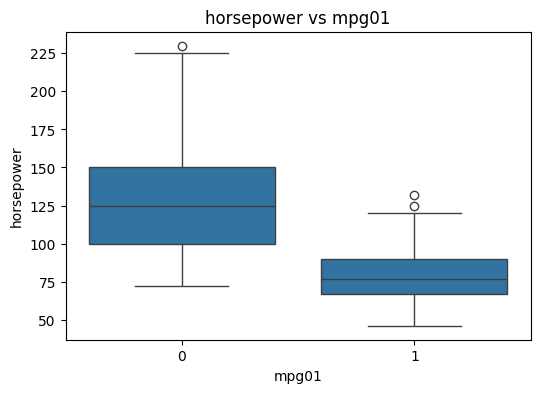

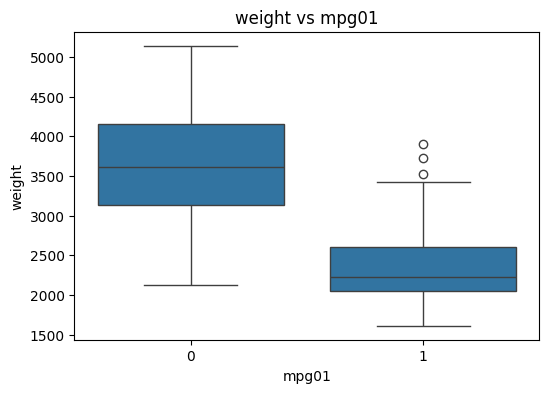

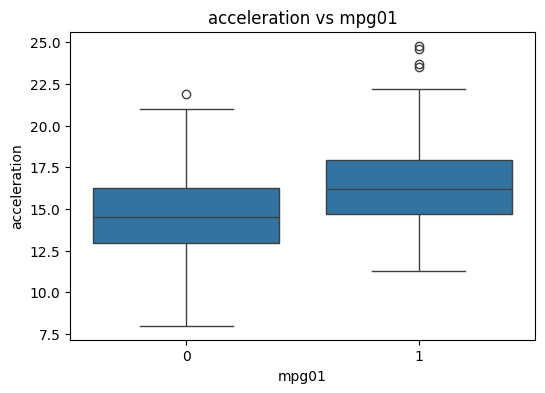

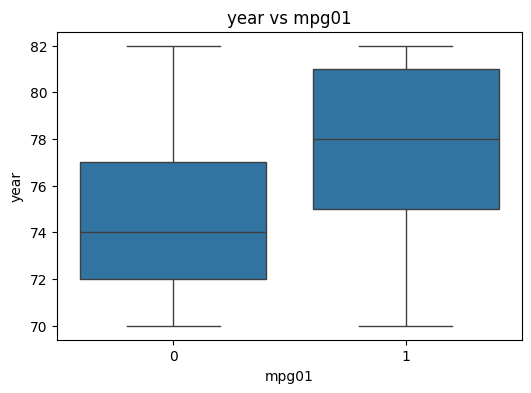

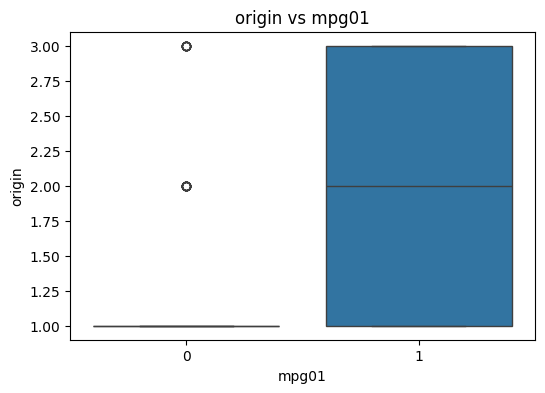

In [ ]:
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']
for col in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='mpg01', y=col, data=auto)
    plt.title(f'{col} vs mpg01')
    plt.show()

If the two boxes for mpg01 = 0 and mpg01 = 1 differ greatly or barely overlap, it means that variable is strongly associated with gas mileage.
- Cars with high gas mileage (mpg01 = 1) are generally lighter. → Heavier cars tend to have lower fuel efficiency.
- Cars with mpg01 = 1 usually have lower horsepower. → High horsepower cars often have worse mileage.
- Cars with smaller engine displacement or fewer cylinders are more likely to have mpg01 = 1. → Smaller engines are more fuel-efficient.

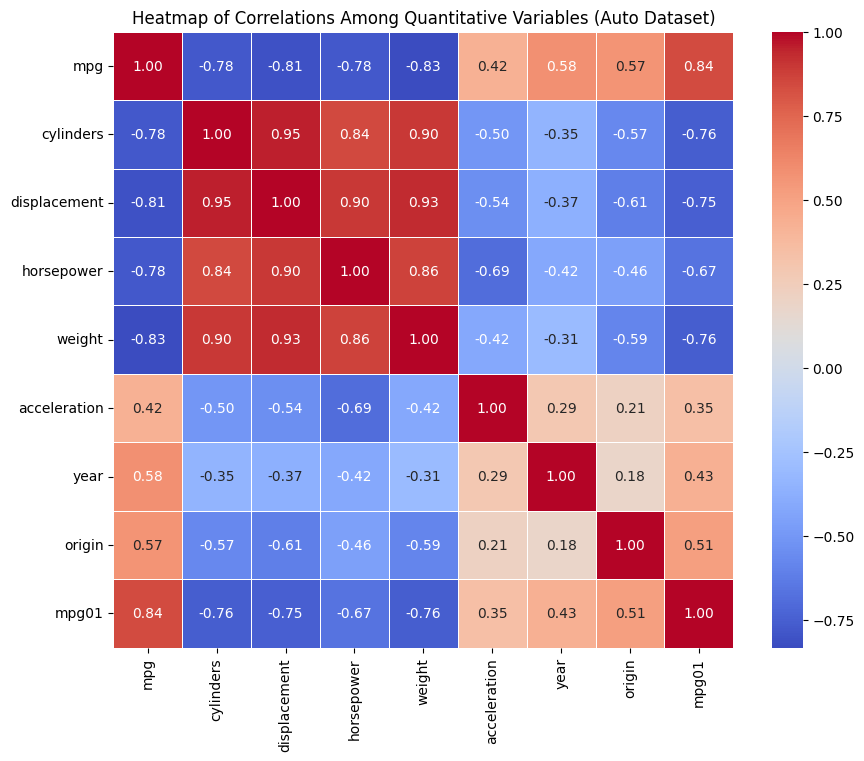

In [ ]:
auto_num = auto.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = auto_num.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap of Correlations Among Quantitative Variables (Auto Dataset)')
plt.show()

mpg01 is negatively correlated with weight, displacement, cylinders, and horsepower

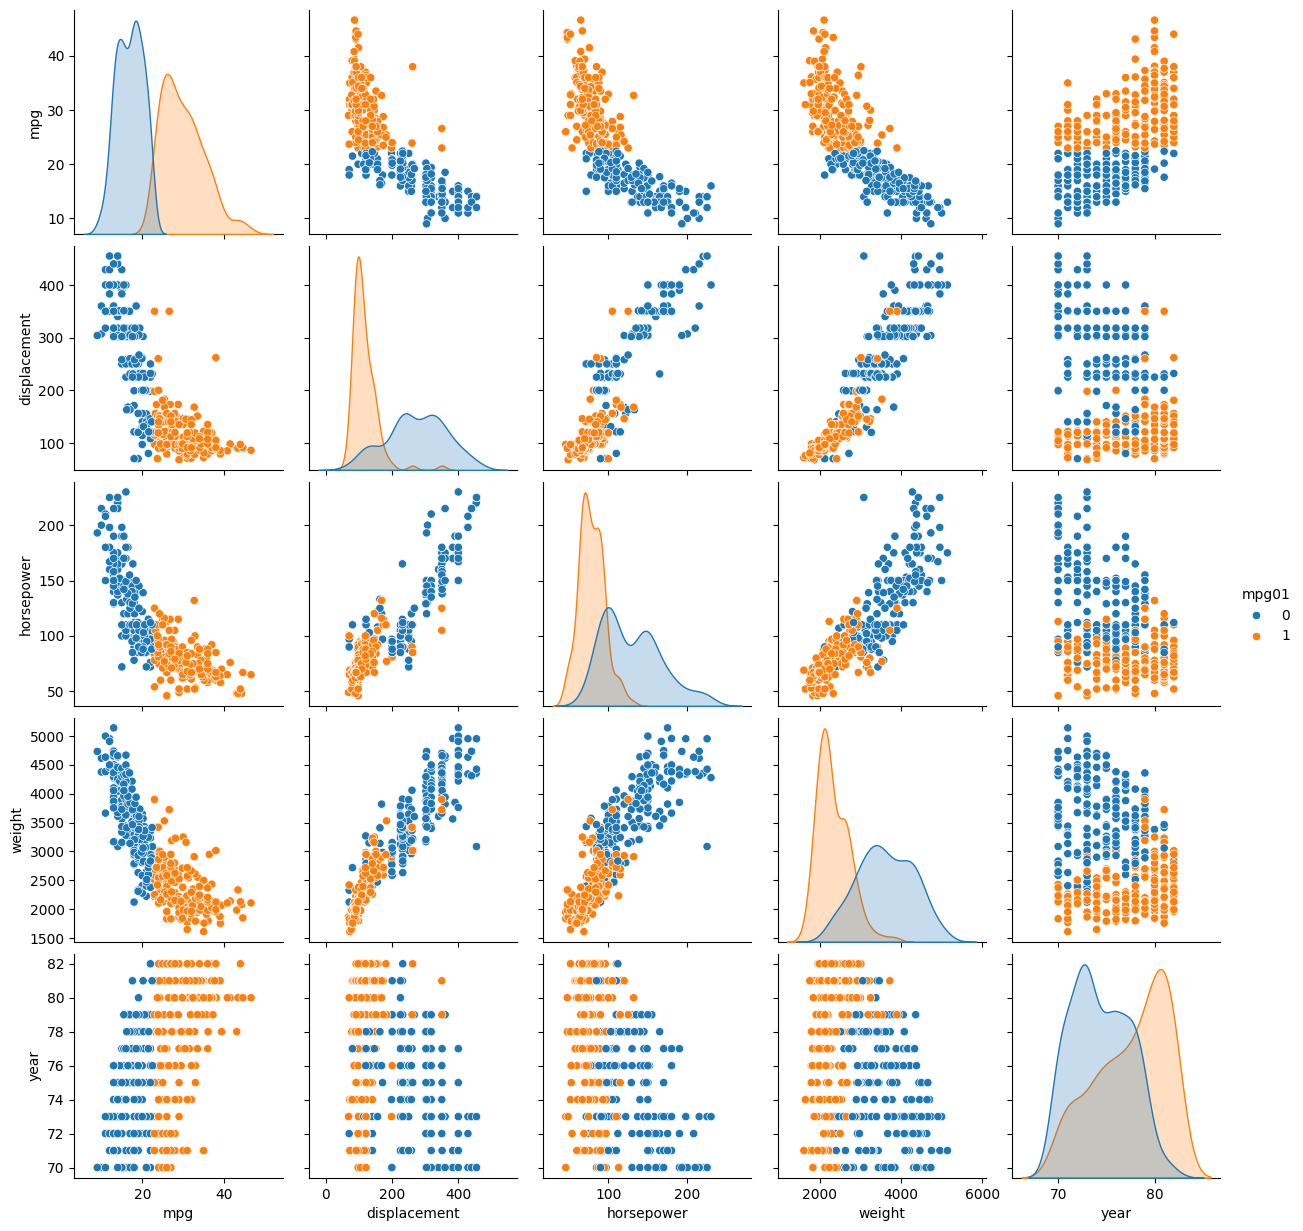

In [ ]:
sns.pairplot(auto, vars=['mpg', 'displacement', 'horsepower', 'weight','year'], hue='mpg01')
plt.show()

####(c) Split the data into a training set and a test set.

In [ ]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(auto, test_size=0.3, random_state=1)

####(d) Perform LDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd

predictors = ['cylinders', 'displacement', 'horsepower', 'weight']

# Train LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(train[predictors], train['mpg01'])
lda_pred = lda.predict(test[predictors])

cm = confusion_matrix(test['mpg01'], lda_pred)
acc = accuracy_score(test['mpg01'], lda_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Confusion Matrix:\n", cm_df)
print("\nTest Accuracy:", round(acc, 3))
print("Test Error Rate:", round(1 - acc, 3))

Confusion Matrix:
           Predicted 0  Predicted 1
Actual 0           58            7
Actual 1            3           50

Test Accuracy: 0.915
Test Error Rate: 0.085


####(e) Perform QDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda = QuadraticDiscriminantAnalysis()
qda.fit(train[predictors], train['mpg01'])

# 在測試集上預測
qda_pred = qda.predict(test[predictors])
qda_prob = qda.predict_proba(test[predictors])  # 若要看機率

# 計算混淆矩陣、準確率與錯誤率
cm = confusion_matrix(test['mpg01'], qda_pred)
accuracy = accuracy_score(test['mpg01'], qda_pred)
test_error = 1 - accuracy

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print(cm_df)
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Test error rate: {test_error:.4f}")

          Predicted 0  Predicted 1
Actual 0           61            4
Actual 1            5           48

Accuracy: 0.9237
Test error rate: 0.0763


####(f) Perform logistic regression on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [ ]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(train[predictors], train['mpg01'])

y_pred = log_model.predict(test[predictors])

# 計算準確率與錯誤率
acc = accuracy_score(test['mpg01'], y_pred)
test_error = 1 - acc
cm = confusion_matrix(test['mpg01'], y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print(cm_df)
print(f"Test Accuracy: {acc:.3f}")
print(f"Test Error Rate: {test_error:.3f}")

          Predicted 0  Predicted 1
Actual 0           59            6
Actual 1            4           49
Test Accuracy: 0.915
Test Error Rate: 0.085


####(g)Perform naive Bayes on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(train[predictors], train['mpg01'])

bayes_pred = nb_model.predict(test[predictors])

# 計算準確率與錯誤率
acc = accuracy_score(test['mpg01'],bayes_pred)
test_error = 1-acc
cm = confusion_matrix(test['mpg01'], bayes_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print(cm_df)
print(f"Test Accuracy: {acc:.3f}")
print(f"Test Error Rate: {test_error:.3f}")

          Predicted 0  Predicted 1
Actual 0           60            5
Actual 1            5           48
Test Accuracy: 0.915
Test Error Rate: 0.085


####(h)Perform KNN on the training data, with several values of K, in order to predict mpg01. Use only the variables that seemed most associated with mpg01 in (b). What test errors do you obtain? Which value of K seems to perform the best on this data set?


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train[predictors])
test_scaled = scaler.transform(test[predictors])

# 嘗試多個 K 值
k_values = range(1,21)
test_errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_scaled, train['mpg01'])
    y_pred = knn.predict(test_scaled)
    acc = accuracy_score(test['mpg01'], y_pred)
    test_error = 1 - acc
    test_errors.append(test_error)
    print(f"K = {k}, Test Error = {test_error:.3f}")

# 找出最佳 K
best_k = k_values[test_errors.index(min(test_errors))]
print(f"\nBest K: {best_k} (Test Error = {min(test_errors):.3f})")

K = 1, Test Error = 0.119
K = 2, Test Error = 0.085
K = 3, Test Error = 0.102
K = 4, Test Error = 0.076
K = 5, Test Error = 0.085
K = 6, Test Error = 0.085
K = 7, Test Error = 0.076
K = 8, Test Error = 0.059
K = 9, Test Error = 0.076
K = 10, Test Error = 0.085
K = 11, Test Error = 0.076
K = 12, Test Error = 0.085
K = 13, Test Error = 0.085
K = 14, Test Error = 0.085
K = 15, Test Error = 0.085
K = 16, Test Error = 0.085
K = 17, Test Error = 0.085
K = 18, Test Error = 0.085
K = 19, Test Error = 0.085
K = 20, Test Error = 0.085

Best K: 8 (Test Error = 0.059)
